# Twitter Network Analysis
This notebook contains a social network analysis mainly executed with the library of NetworkX. In detail, this dataset consists of 'circles' (or 'lists') from Twitter. Twitter data was crawled from public sources. The dataset includes node features (profiles), circles, and ego networks. The dataset can be found at this link: [Stanford Twitter Dataset](https://snap.stanford.edu/data/ego-Twitter.html).

## Import packages

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

## Analysis
The edges are loaded from the `data` folder and saved in a dataframe. Each edge is a new row and for each edge there is a `start_node` and an `end_node` column

In [ ]:
twitter = pd.read_csv(
    "https://snap.stanford.edu/data/twitter_combined.txt.gz",
    compression="gzip",
    sep=" ",
    names=["start_node", "end_node"],
)
twitter = twitter.iloc[:80000]

The graph is created from the `twitter` dataframe of the edges:

In [ ]:
G = nx.from_pandas_edgelist(twitter, "start_node", "end_node")

## Visualizing the graph

Let's start our exploration by visualizing the graph. Visualization plays a
central role in exploratory data analysis to help get a qualitative feel for
the data.

Since we don't have any real sense of structure in the data, let's start by
viewing the graph with `random_layout`, which is among the fastest of the layout
functions.

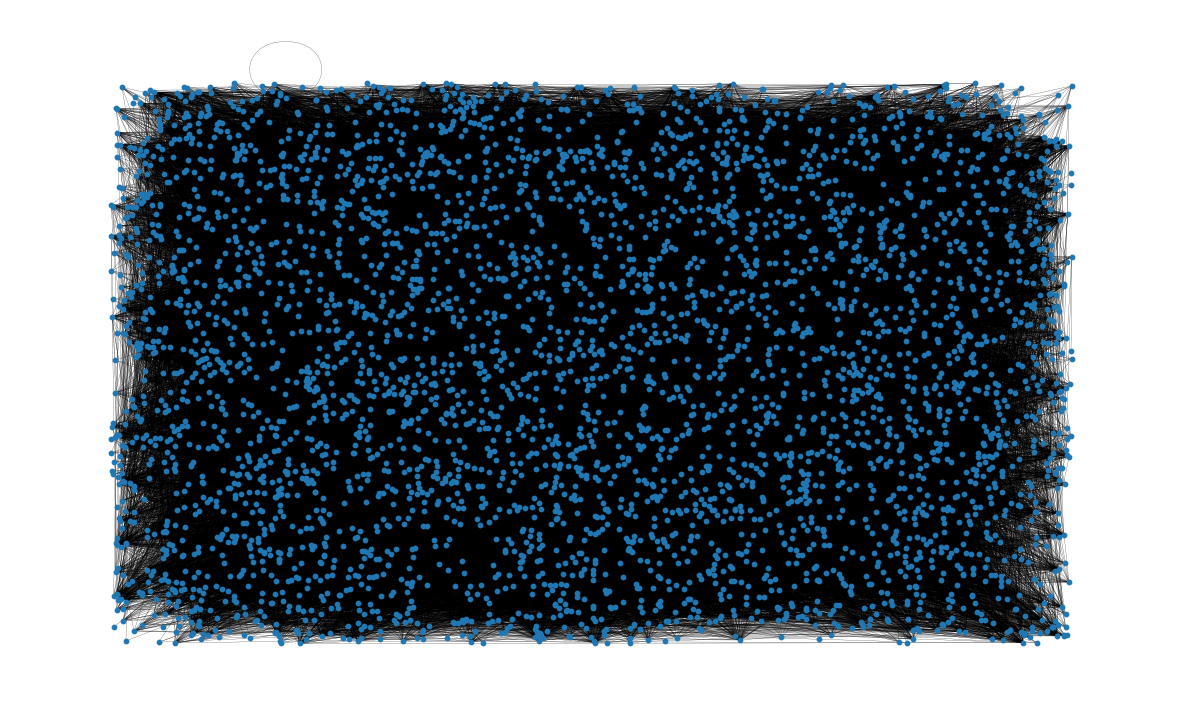

In [ ]:
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)

Do we need more or less information (nodes or edges) from the graph to do the analysis? Let's check `spring_layout` and continue analysis...

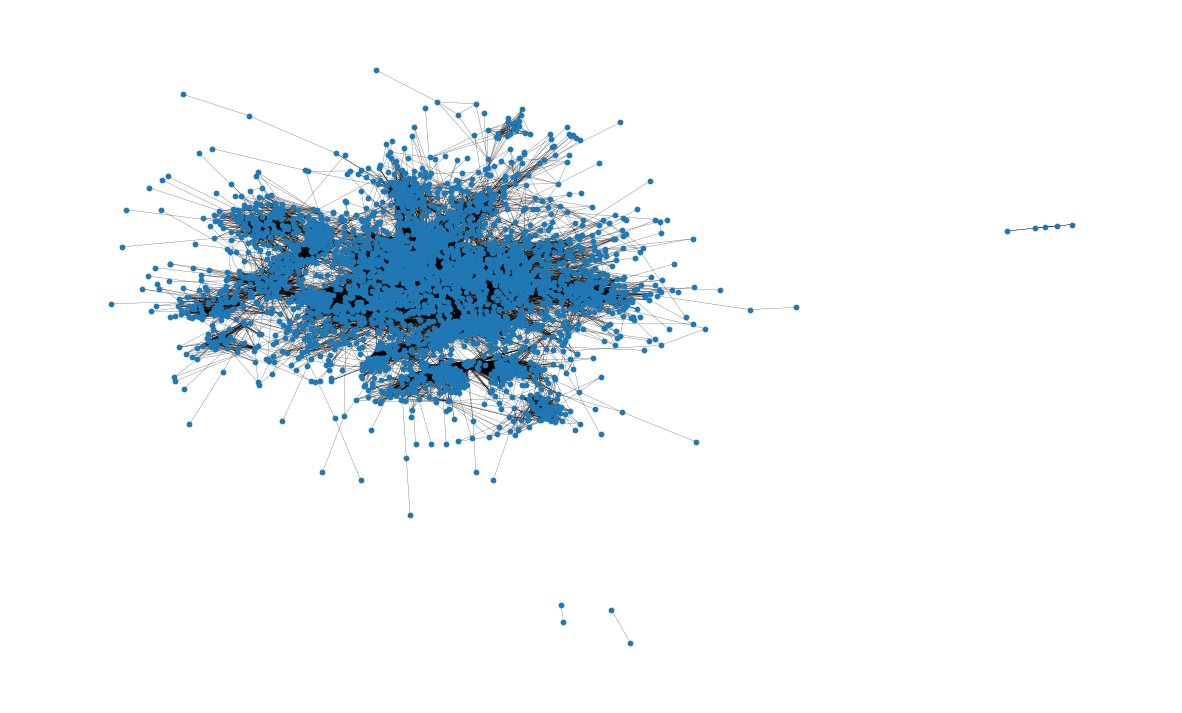

In [ ]:
pos = nx.spring_layout(G, iterations=15, seed=1721)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

What other information can we extract from this network? ... (check graphs metrics)

## Network Communities

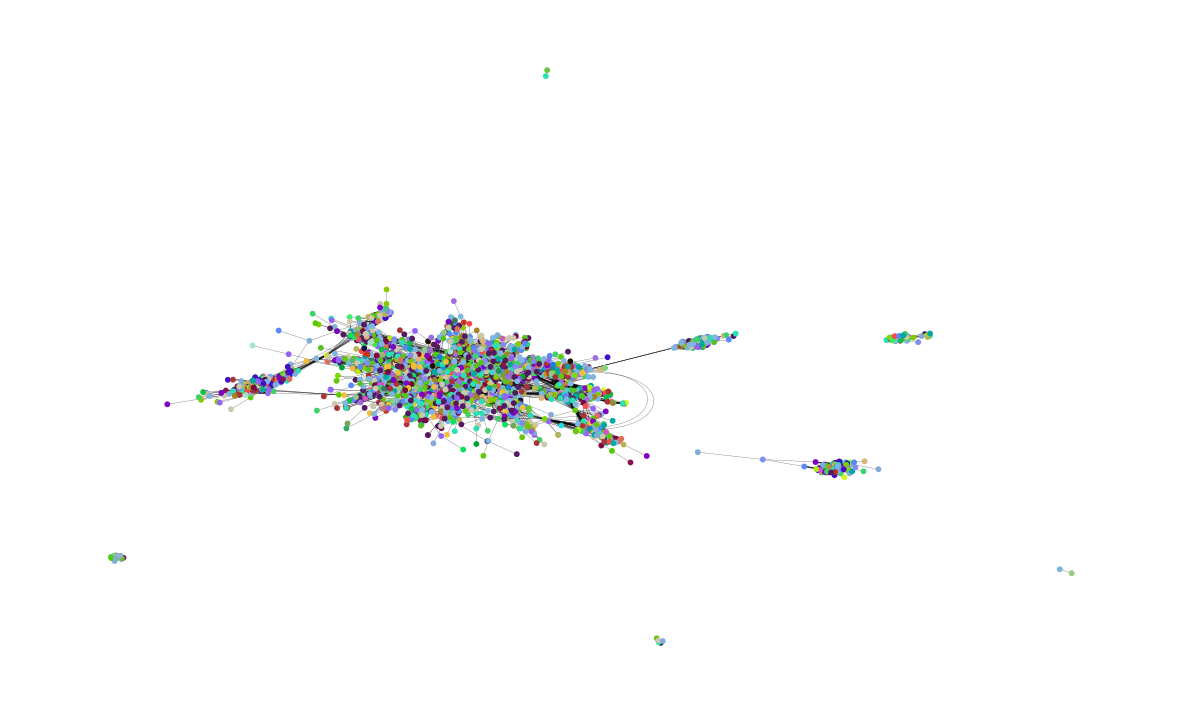

In [ ]:
!pip install networkx
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

colors = ["" for x in range(G.number_of_nodes())]  # initialize colors list
counter = 0
for com in nx.community.label_propagation_communities(G):
    color = "#%06X" % randint(0, 0xFFFFFF)  # Creates random RGB color
    counter += 1
    for node in list(com):
        # Ensure the 'colors' list is large enough
        if node >= len(colors):
            colors.extend([""] * (node - len(colors) + 1))
        colors[node] = color  # Assign the color to the node

counter

pos = nx.spring_layout(G)

plt.figure(figsize=(15, 9))
plt.axis("off")
# Before calling draw_networkx, filter out empty strings from colors
valid_colors = [c for c in colors if c] # Filter out empty strings
nx.draw_networkx(
    G, pos=pos, node_size=10, with_labels=False, width=0.15, node_color=valid_colors
)
plt.show()

##Basic topological attributes

In [ ]:
#Total number of nodes in network:
G.number_of_nodes()

4316

La red contiene 4316 nodos, donde cada nodo representa una entidad única dentro de la red

In [ ]:
#Total number of edges:
G.number_of_edges()

58270

La red tiene 58270 aristas, que son las conexiones o relaciones entre los nodos

In [ ]:
np.mean([d for _, d in G.degree()])
# En promedio un nodo esta conectado con al menos 27 otros nodos

27.00185356811863

## Auxiliary functions

In [ ]:
# draw a simple graph
def draw_graph(G, node_names={}, filename=None, node_size=50):
    pos_nodes = nx.spring_layout(G)
    nx.draw(G, pos_nodes, with_labels=False, node_size=node_size, edge_color='gray')

    pos_attrs = {}
    for node, coords in pos_nodes.items():
        pos_attrs[node] = (coords[0], coords[1] + 0.08)

    nx.draw_networkx_labels(G, pos_attrs, labels=node_names, font_family='serif')

    plt.axis('off')
    axis = plt.gca()
    axis.set_xlim([1.2*x for x in axis.get_xlim()])
    axis.set_ylim([1.2*y for y in axis.get_ylim()])

    if filename:
        plt.savefig(filename, format="png")


# draw enhanced path on the graph
def draw_enhanced_path(G, path_to_enhance, node_names={}, filename=None):
    path_edges = list(zip(path,path[1:]))
    pos_nodes = nx.spring_layout(G)

    plt.figure(figsize=(5,5),dpi=300)
    pos_nodes = nx.spring_layout(G)
    nx.draw(G, pos_nodes, with_labels=False, node_size=50, edge_color='gray')

    pos_attrs = {}
    for node, coords in pos_nodes.items():
        pos_attrs[node] = (coords[0], coords[1] + 0.08)

    nx.draw_networkx_labels(G, pos_attrs, labels=node_names, font_family='serif')
    nx.draw_networkx_edges(G,pos_nodes,edgelist=path_edges, edge_color='#cc2f04', style='dashed', width=2.0)

    plt.axis('off')
    axis = plt.gca()
    axis.set_xlim([1.2*x for x in axis.get_xlim()])
    axis.set_ylim([1.2*y for y in axis.get_ylim()])

    if filename:
        plt.savefig(filename, format="png")

##Shortest path

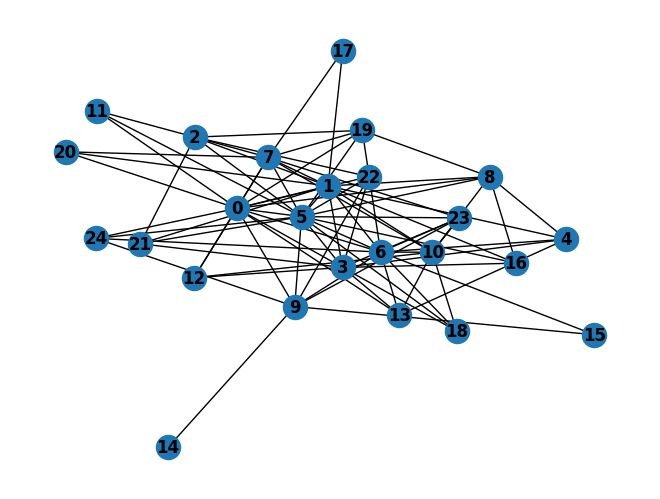

In [ ]:
import networkx as nx
import random
random.seed(2345)
def generar_grafo():
    G = nx.Graph()

    # Agregar 5 nodos al grafo
    nodos = {i: f"{i}" for i in range(25)}
    G.add_nodes_from(nodos)

    # Crear conexiones aleatorias entre los nodos
    for i in range(11):
        for _ in range(random.randint(0, 15)):  # Generar hasta 10 conexiones por nodo
            nodo_destino = random.choice(list(nodos.keys()))  # Elegir un nodo destino aleatorio
            G.add_edge(i, nodo_destino)

    return G

# Generar el grafo y visualizarlo
grafo = generar_grafo()
nx.draw(grafo, with_labels=True, font_weight='bold')

El camino más corto entre el nodo 0 y el nodo 24 es: [0, 24]
[0, 24]


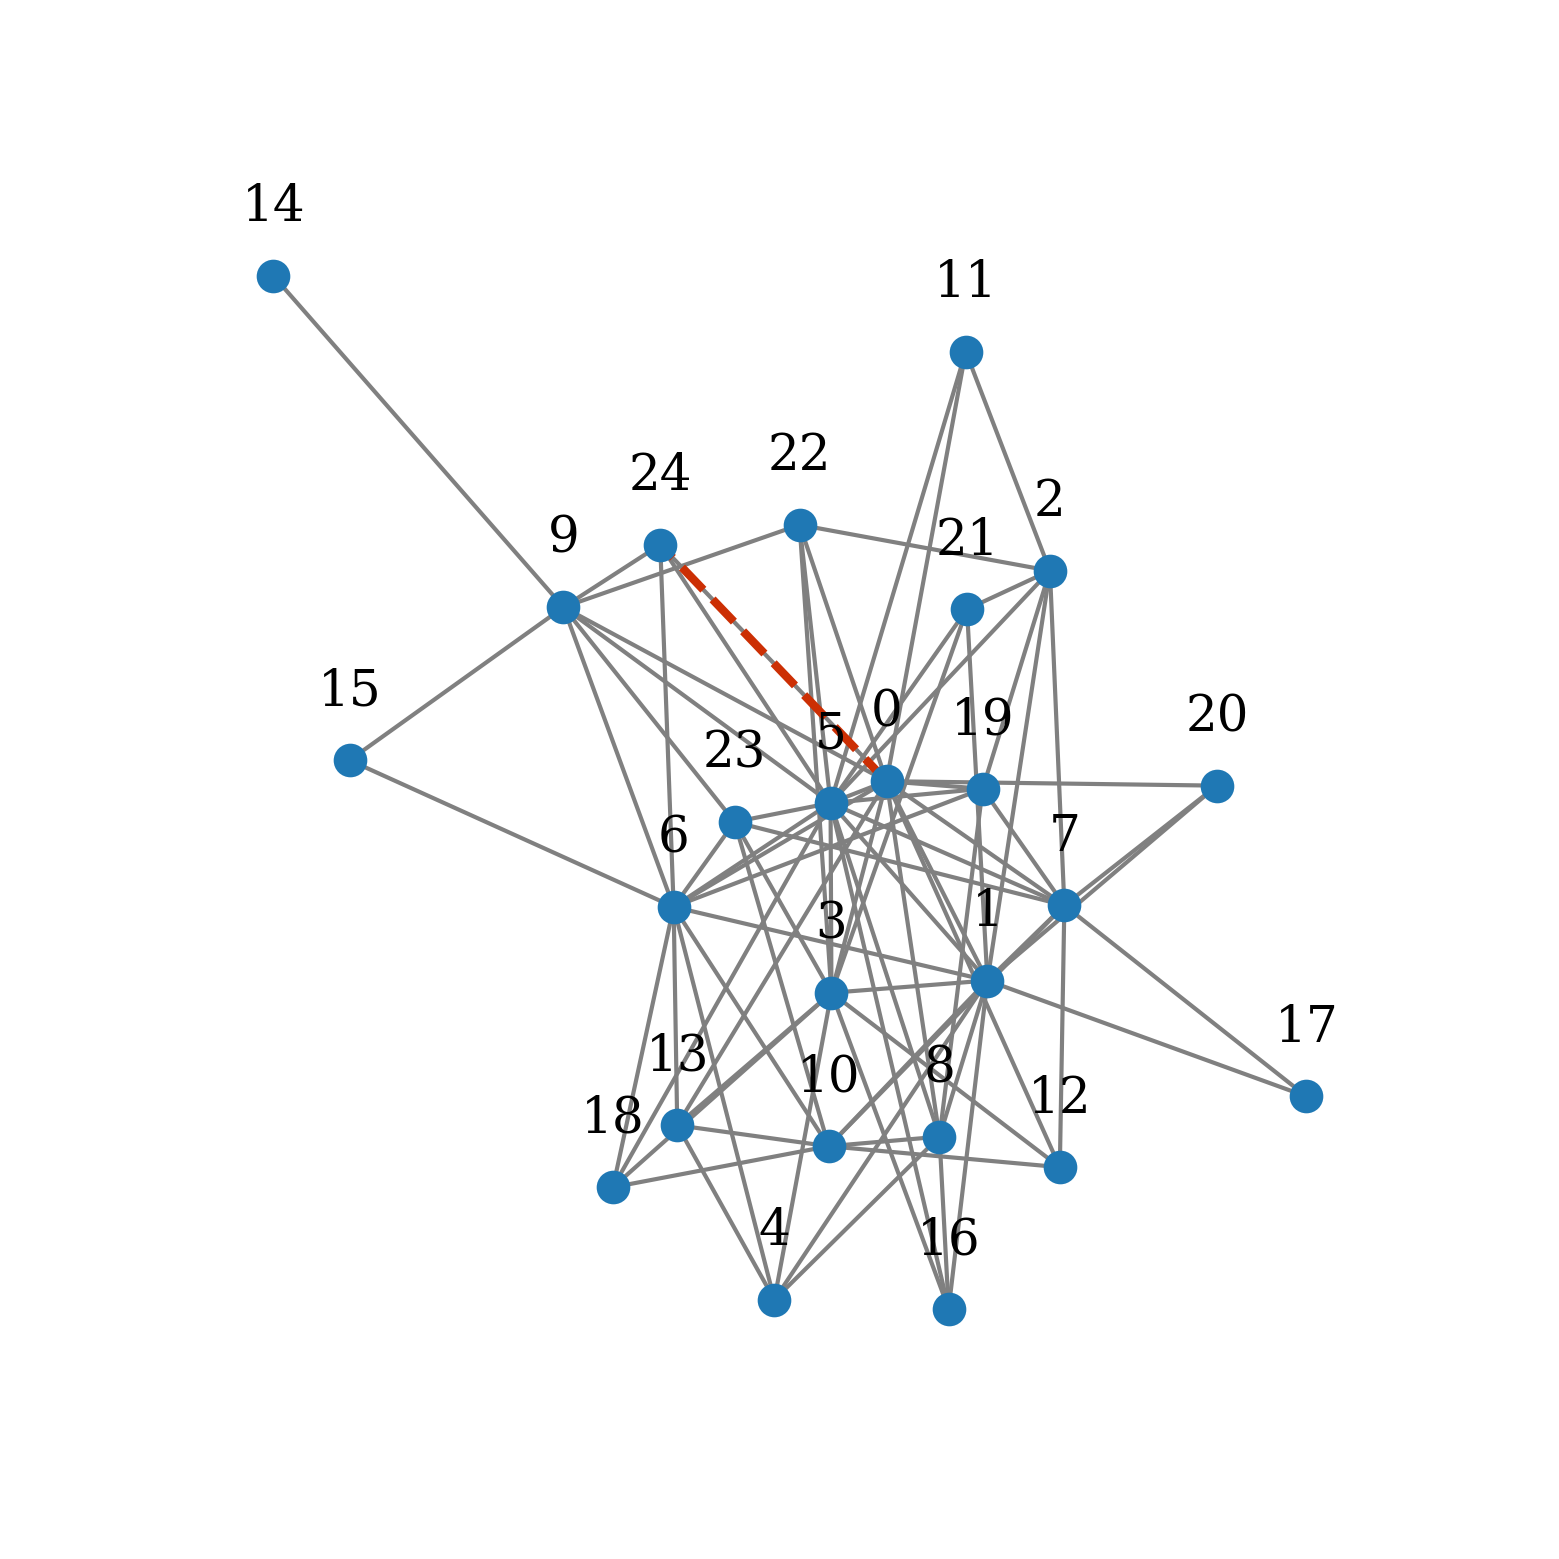

In [ ]:
# Determinar los nodos de inicio y fin para encontrar el camino más corto
nodo_inicio = 0
nodo_fin = 24

# Encontrar el camino más corto entre los nodos de inicio y fin
camino_mas_corto = nx.shortest_path(grafo, source=nodo_inicio, target=nodo_fin)

print(f"El camino más corto entre el nodo {nodo_inicio} y el nodo {nodo_fin} es: {camino_mas_corto}")

path = nx.shortest_path(grafo,source=nodo_inicio,target=nodo_fin)
print(path)

nodos = {i: f"{i}" for i in range(25)}
draw_enhanced_path(grafo, path, node_names=nodos,filename='shortest_path.png')

##Efficiency

In [ ]:
print(nx.global_efficiency(grafo))
print(nx.local_efficiency(grafo))

0.6158333333333333
0.7302301587301585


1. La eficiencia global de la red es 0.6158, lo que indica una buena capacidad para transmitir información entre nodos distantes, aunque no de manera óptima.

2. La eficiencia local es 0.7302, mostrando una alta interconectividad en las vecindades inmediatas de cada nodo. Esto sugiere que la red es más eficiente en la transmisión de información a nivel local que global, lo que es característico de estructuras con comunidades bien definidas.

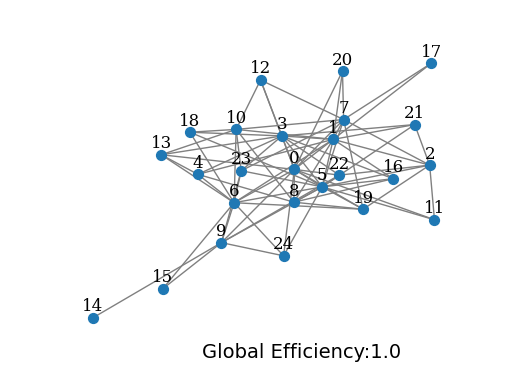

In [ ]:
# higher efficiency
G = nx.complete_graph(n=20)

ge = round(nx.global_efficiency(G),2)

# place the text box in axes coords
ax = plt.gca()
ax.text(-.4, -1.3, "Global Efficiency:{}".format(ge), fontsize=14, ha='left', va='bottom');

draw_graph(grafo,node_names=nodos,filename='efficiency.png')

 cada nodo está directamente conectado con todos los demás nodos.

 La distancia más corta entre cualquier par de nodos es siempre 1, porque cualquier nodo puede llegar a cualquier otro nodo en un solo paso.

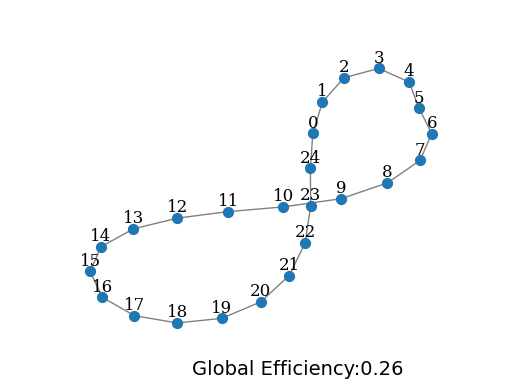

In [ ]:
# lower efficiency
G = nx.cycle_graph(n=25)

le = round(nx.global_efficiency(G),2)

# place the text box in axes coords
ax = plt.gca()
ax.text(-.4, -1.3, "Global Efficiency:{}".format(le), fontsize=14, ha='left', va='bottom');

draw_graph(G, node_names=nodos,filename='less_efficiency.png')

Una eficiencia global de 0.26 indica que, en promedio, las distancias más cortas entre los nodos no son muy eficientes. En este grafo, muchos nodos deben pasar por varios otros nodos para alcanzar su destino, lo que aumenta las distancias de comunicación.

##Clustering coefficient

In [ ]:
nx.average_clustering(grafo)

0.537928182928183

El análisis de la red social de Twitter muestra un coeficiente de agrupamiento promedio de 0.5379, indicando un nivel moderado de agrupamiento. Esto sugiere la formación de comunidades interconectadas, típicas de redes donde los amigos de un usuario suelen estar también conectados entre sí.

In [ ]:
nx.clustering(grafo)

{0: 0.3076923076923077,
 1: 0.3333333333333333,
 2: 0.42857142857142855,
 3: 0.2727272727272727,
 4: 0.5,
 5: 0.325,
 6: 0.3181818181818182,
 7: 0.35555555555555557,
 8: 0.42857142857142855,
 9: 0.39285714285714285,
 10: 0.2857142857142857,
 11: 0.6666666666666666,
 12: 0.5,
 13: 0.5,
 14: 0,
 15: 1.0,
 16: 0.8333333333333334,
 17: 1.0,
 18: 0.5,
 19: 0.6,
 20: 1.0,
 21: 0.8333333333333334,
 22: 0.6,
 23: 0.4666666666666667,
 24: 1.0}

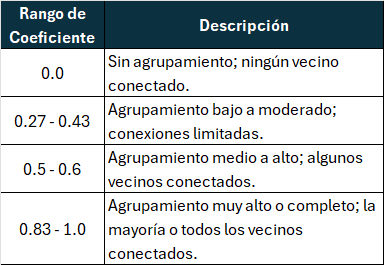

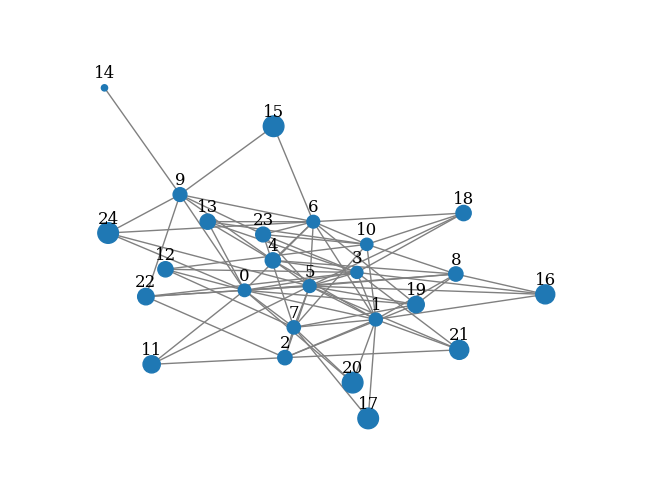

In [ ]:
cc = nx.clustering(grafo)
node_size=[(v + 0.1) * 200 for v in cc.values()]
draw_graph(grafo, node_names=nodos, node_size=node_size,filename='clustering.png')

##Centrality

In [ ]:
nx.degree_centrality(grafo)

{0: 0.5833333333333333,
 1: 0.5416666666666666,
 2: 0.29166666666666663,
 3: 0.4583333333333333,
 4: 0.20833333333333331,
 5: 0.6666666666666666,
 6: 0.5,
 7: 0.41666666666666663,
 8: 0.29166666666666663,
 9: 0.3333333333333333,
 10: 0.3333333333333333,
 11: 0.125,
 12: 0.16666666666666666,
 13: 0.20833333333333331,
 14: 0.041666666666666664,
 15: 0.08333333333333333,
 16: 0.16666666666666666,
 17: 0.08333333333333333,
 18: 0.16666666666666666,
 19: 0.25,
 20: 0.125,
 21: 0.16666666666666666,
 22: 0.20833333333333331,
 23: 0.25,
 24: 0.16666666666666666}

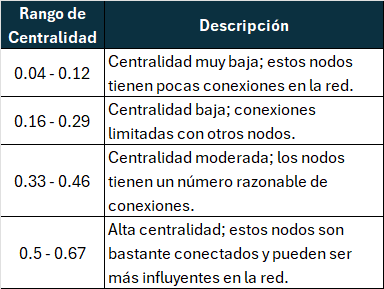

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Degree centrality,0.583333,0.541667,0.291667,0.458333,0.208333,0.666667,0.5,0.416667,0.291667,0.333333,...,0.083333,0.166667,0.083333,0.166667,0.25,0.125,0.166667,0.208333,0.25,0.166667


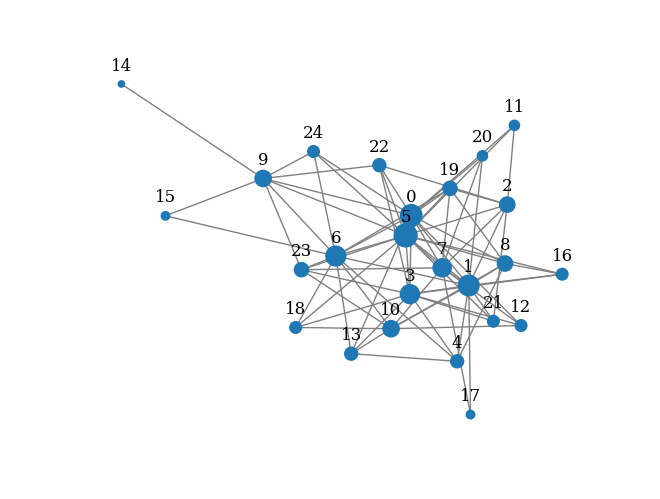

In [ ]:
dc = nx.degree_centrality(grafo)
node_size=[(v + 0.01) * 400 for v in dc.values()]
draw_graph(grafo, node_names=nodos, node_size=node_size,filename='deg_centr.png')

df = pd.DataFrame(dc,index=['Degree centrality'])
df.columns = nodos.values()
df

In [ ]:
nx.closeness_centrality(grafo)

{0: 0.7058823529411765,
 1: 0.6666666666666666,
 2: 0.5454545454545454,
 3: 0.6153846153846154,
 4: 0.5333333333333333,
 5: 0.75,
 6: 0.6666666666666666,
 7: 0.6,
 8: 0.5581395348837209,
 9: 0.5853658536585366,
 10: 0.5581395348837209,
 11: 0.48,
 12: 0.5217391304347826,
 13: 0.5217391304347826,
 14: 0.375,
 15: 0.42857142857142855,
 16: 0.5217391304347826,
 17: 0.43636363636363634,
 18: 0.5106382978723404,
 19: 0.5581395348837209,
 20: 0.5,
 21: 0.5217391304347826,
 22: 0.5333333333333333,
 23: 0.5714285714285714,
 24: 0.5333333333333333}

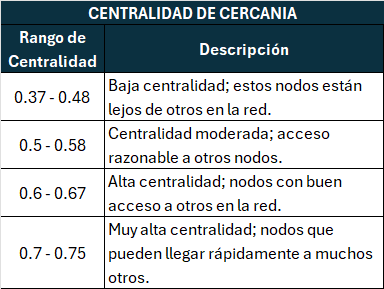

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Closeness centrality,0.705882,0.666667,0.545455,0.615385,0.533333,0.75,0.666667,0.6,0.55814,0.585366,...,0.428571,0.521739,0.436364,0.510638,0.55814,0.5,0.521739,0.533333,0.571429,0.533333


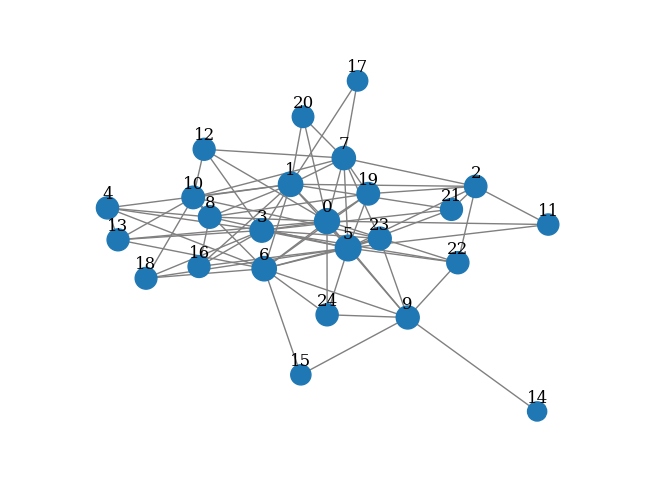

In [ ]:
dc = nx.closeness_centrality(grafo)
node_size=[(v + 0.1) * 400 for v in dc.values()]
draw_graph(grafo, node_names=nodos, node_size=node_size,filename='clos_centr.png')

df = pd.DataFrame(dc,index=['Closeness centrality'])
df.columns = nodos.values()
df

In [ ]:
nx.betweenness_centrality(grafo)

{0: 0.14791405253361778,
 1: 0.12445880910554823,
 2: 0.018262594893029675,
 3: 0.07124166091557395,
 4: 0.005304794842838321,
 5: 0.17488308289938725,
 6: 0.12207001432544909,
 7: 0.0638960777547734,
 8: 0.0146911663216011,
 9: 0.11162635673505239,
 10: 0.030383022774327122,
 11: 0.0008303140096618357,
 12: 0.0026570048309178737,
 13: 0.004772099880795533,
 14: 0.0,
 15: 0.0,
 16: 0.0007246376811594203,
 17: 0.0,
 18: 0.002779346257607127,
 19: 0.006984702093397745,
 20: 0.0,
 21: 0.0011322463768115942,
 22: 0.008451361440491877,
 23: 0.014472886212016646,
 24: 0.0}

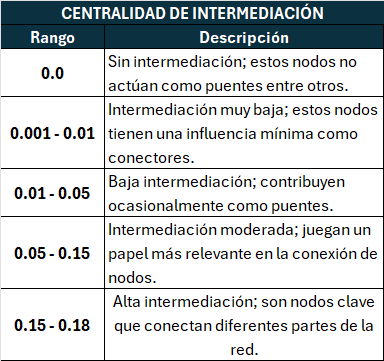

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Betweenness centrality,0.147914,0.124459,0.018263,0.071242,0.005305,0.174883,0.12207,0.063896,0.014691,0.111626,...,0.0,0.000725,0.0,0.002779,0.006985,0.0,0.001132,0.008451,0.014473,0.0


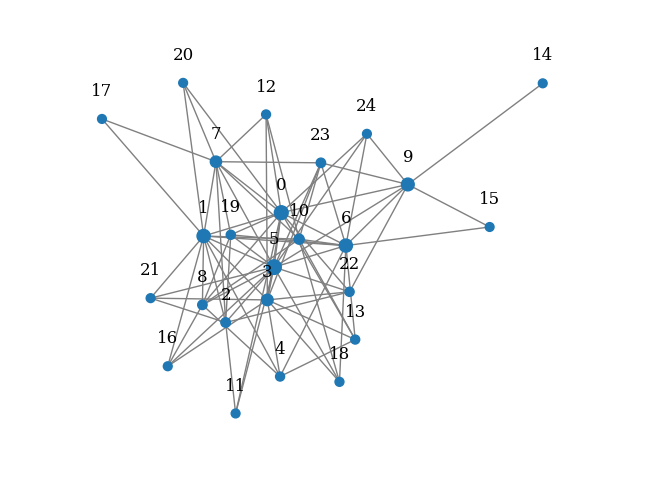

In [ ]:
dc = nx.betweenness_centrality(grafo)
node_size=[(v + 0.1) * 400 for v in dc.values()]
draw_graph(grafo, node_names=nodos, node_size=node_size,filename='bet_centrality.png')

df = pd.DataFrame(dc,index=['Betweenness centrality'])
df.columns = nodos.values()
df

##Assortativity

In [ ]:
nx.degree_pearson_correlation_coefficient(grafo)

-0.3382124079915878


El coeficiente de correlación de Pearson de los grados es -0.3382, lo que significa que en esta red, los nodos muy conectados tienden a estar vinculados con nodos que tienen pocas conexiones. Esto indica que la red es desasortativa, donde los nodos más influyentes prefieren conectarse con nodos menos conectados, en lugar de agruparse entre sí.

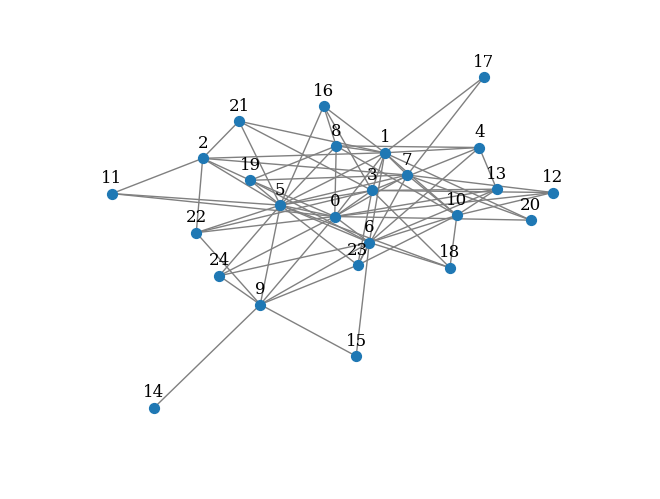

In [ ]:
draw_graph(grafo, node_names=nodos,filename='assortativity.png')

##Modularity

In [ ]:
import networkx.algorithms.community as nx_comm
# partitions can be provided manually
print(nx_comm.modularity(grafo, communities=[{0,1,2,3,4,5,6,7,8,9,10,11,12},{13,14,15,16,17,18,19,20,21,22,23,24}]))

# or automatically computed using networkx
print(nx_comm.modularity(grafo, nx_comm.label_propagation_communities(G)))

-0.1573468173706128
-0.08536585365853658


El índice de modularidad es negativo tanto para las comunidades definidas manualmente (-0.1573) como para las generadas automáticamente (-0.0854). Esto sugiere que la red no se organiza en comunidades claramente definidas, es decir, las conexiones no están agrupadas de manera efectiva en grupos cohesivos.

## Transitivity

In [ ]:
nx.transitivity(grafo)

0.37327188940092165

El valor de transitividad de la red es 0.3733, lo que indica que aproximadamente el 37.3% de las posibles conexiones en triángulos están presentes. Esto refleja un nivel moderado de cohesión global, sugiriendo que, en general, los nodos de la red tienen una tendencia a formar agrupaciones o triángulos, pero no de manera muy pronunciada.